In [1]:
import os
import random

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import STL10, OxfordIIITPet
from tqdm.auto import tqdm

# Фиксация сидов для воспроизводимости
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("high")
USE_AMP = device.type == "cuda"

print(f"Используемое устройство: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version (torch): {torch.version.cuda}")
else:
    print("ВНИМАНИЕ: CUDA недоступна в текущем kernel. Переключите kernel на .venv с CUDA-сборкой torch.")

os.makedirs("artifacts", exist_ok=True)
os.makedirs("artifacts/figures", exist_ok=True)

Используемое устройство: cpu
ВНИМАНИЕ: CUDA недоступна в текущем kernel. Переключите kernel на .venv с CUDA-сборкой torch.


c:\Users\Maxim\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Формат батча STL10: torch.Size([64, 3, 96, 96])


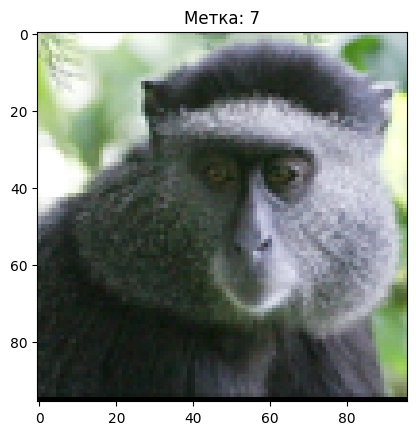

Формат батча Pet: torch.Size([4, 3, 128, 128]), маски: torch.Size([4, 128, 128])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.007843137..1.08956].


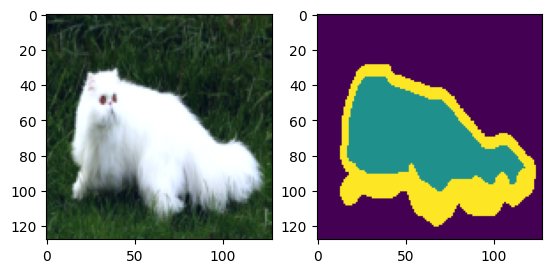

In [ ]:
# Трансформы для части A (Классификация)
basic_transform = T.Compose([
    T.Resize((96, 96)),
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

aug_transform = T.Compose([
    T.Resize((96, 96)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Явно фиксируем pretrained веса и preprocessing для ResNet18
resnet18_weights = torchvision.models.ResNet18_Weights.DEFAULT
resnet_transform = resnet18_weights.transforms()
print(f"ResNet18 pretrained weights: {resnet18_weights}")

# На Windows + notebook безопаснее num_workers=0, чтобы избежать PicklingError
num_workers = 0
loader_kwargs = {
    "batch_size": 64,
    "num_workers": num_workers,
    "pin_memory": (device.type == "cuda"),
}
if num_workers > 0:
    loader_kwargs["persistent_workers"] = True

# Загрузка датасетов
# Часть A: STL10
train_ds = STL10(root="data", split='train', download=True, transform=basic_transform)
test_ds = STL10(root="data", split='test', download=True, transform=basic_transform)

# Разделение на train/val
val_size = int(0.2 * len(train_ds))
train_indices = list(range(len(train_ds)))
np.random.shuffle(train_indices)
val_ds = Subset(train_ds, train_indices[:val_size])
train_subset = Subset(train_ds, train_indices[val_size:])

train_loader = DataLoader(train_subset, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_ds, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_ds, shuffle=False, **loader_kwargs)

# Часть B: OxfordIIITPet (Сегментация)
def target_transform(mask):
    mask = np.array(mask, dtype=np.int64) - 1  # перевод из 1-based в 0-based
    mask = np.clip(mask, 0, 2)
    return torch.from_numpy(mask).long()

seg_transform = T.Compose([
    T.Resize((128, 128)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

seg_target_transform = T.Compose([
    T.Resize((128, 128), interpolation=T.InterpolationMode.NEAREST),
])

def pet_target_transform(x):
    return target_transform(seg_target_transform(x))

pet_ds = OxfordIIITPet(
    root="data",
    split='test',
    target_types='segmentation',
    download=True,
    transform=seg_transform,
    target_transform=pet_target_transform,
 )

pet_loader_kwargs = {
    "batch_size": 4,
    "shuffle": True,
    "num_workers": num_workers,
    "pin_memory": (device.type == "cuda"),
}
if num_workers > 0:
    pet_loader_kwargs["persistent_workers"] = True

pet_loader = DataLoader(pet_ds, **pet_loader_kwargs)

# Проверка данных (Sanity Check)
images, labels = next(iter(train_loader))
print(f"Формат батча STL10: {images.shape}")
plt.imshow(images[0].permute(1, 2, 0) * 0.5 + 0.5)
plt.title(f"Метка: {labels[0].item()}")
plt.show()

# Проверка сегментации
images, masks = next(iter(pet_loader))
print(f"Формат батча Pet: {images.shape}, маски: {masks.shape}")
plt.subplot(1, 2, 1)
plt.imshow(images[0].permute(1, 2, 0) * 0.229 + 0.485)
plt.subplot(1, 2, 2)
plt.imshow(masks[0])
plt.show()

In [ ]:
# Часть A: Классификация (C1-C4)
import torchvision.models as models

# Простая CNN
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Flatten(),
            nn.Linear(64 * 24 * 24, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.conv_layers(x)


def train_one_epoch(model, loader, optimizer, criterion, device, scaler):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / max(len(loader), 1), 100.0 * correct / max(total, 1)


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                outputs = model(images)
                loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / max(len(loader), 1), 100.0 * correct / max(total, 1)


def run_classification_experiment(config_name, model, train_loader_local, val_loader_local, epochs=2):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam((p for p in model.parameters() if p.requires_grad), lr=0.001)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = -1.0

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader_local, optimizer, criterion, device, scaler)
        val_loss, val_acc = evaluate(model, val_loader_local, criterion, device)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        print(f"{config_name} | Эпоха {epoch + 1}/{epochs}: train_acc={train_acc:.2f}%, val_acc={val_acc:.2f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f"artifacts/best_model_{config_name}.pth")

    return history, best_val_acc


# Единые индексы train/val для честного сравнения
val_indices = train_indices[:val_size]
train_only_indices = train_indices[val_size:]

def make_loader(dataset, shuffle=False, batch_size=64):
    kwargs = {
        "batch_size": batch_size,
        "shuffle": shuffle,
        "num_workers": num_workers,
        "pin_memory": (device.type == "cuda"),
    }
    if num_workers > 0:
        kwargs["persistent_workers"] = True
    return DataLoader(dataset, **kwargs)

# Датасеты под разные трансформы
train_basic_full = STL10(root="data", split='train', download=True, transform=basic_transform)
train_aug_full = STL10(root="data", split='train', download=False, transform=aug_transform)
train_resnet_full = STL10(root="data", split='train', download=False, transform=resnet_transform)
test_basic_full = STL10(root="data", split='test', download=False, transform=basic_transform)
test_resnet_full = STL10(root="data", split='test', download=False, transform=resnet_transform)

train_loader_c1 = make_loader(Subset(train_basic_full, train_only_indices), shuffle=True)
val_loader_c1 = make_loader(Subset(train_basic_full, val_indices), shuffle=False)
train_loader_c2 = make_loader(Subset(train_aug_full, train_only_indices), shuffle=True)
val_loader_c2 = val_loader_c1
train_loader_resnet = make_loader(Subset(train_resnet_full, train_only_indices), shuffle=True)
val_loader_resnet = make_loader(Subset(train_resnet_full, val_indices), shuffle=False)
test_loader_basic = make_loader(test_basic_full, shuffle=False)
test_loader_resnet = make_loader(test_resnet_full, shuffle=False)

history_by_config = {}
classification_results = []

# C1: simple-cnn-base
model_c1 = SimpleCNN().to(device)
history_c1, best_acc_c1 = run_classification_experiment("C1", model_c1, train_loader_c1, val_loader_c1, epochs=2)
history_by_config["C1"] = history_c1
classification_results.append({"experiment_id": "C1", "desc": "simple-cnn-base", "best_val_accuracy": best_acc_c1})

# C2: simple-cnn-aug
model_c2 = SimpleCNN().to(device)
history_c2, best_acc_c2 = run_classification_experiment("C2", model_c2, train_loader_c2, val_loader_c2, epochs=2)
history_by_config["C2"] = history_c2
classification_results.append({"experiment_id": "C2", "desc": "simple-cnn-aug", "best_val_accuracy": best_acc_c2})

# C3: resnet18-head-only
model_c3 = models.resnet18(weights=resnet18_weights)
for p in model_c3.parameters():
    p.requires_grad = False
model_c3.fc = nn.Linear(model_c3.fc.in_features, 10)
for p in model_c3.fc.parameters():
    p.requires_grad = True
model_c3 = model_c3.to(device)
history_c3, best_acc_c3 = run_classification_experiment("C3", model_c3, train_loader_resnet, val_loader_resnet, epochs=2)
history_by_config["C3"] = history_c3
classification_results.append({"experiment_id": "C3", "desc": "resnet18-head-only", "best_val_accuracy": best_acc_c3})

# C4: resnet18-finetune (layer4 + fc)
model_c4 = models.resnet18(weights=resnet18_weights)
for p in model_c4.parameters():
    p.requires_grad = False
for p in model_c4.layer4.parameters():
    p.requires_grad = True
model_c4.fc = nn.Linear(model_c4.fc.in_features, 10)
for p in model_c4.fc.parameters():
    p.requires_grad = True
model_c4 = model_c4.to(device)
history_c4, best_acc_c4 = run_classification_experiment("C4", model_c4, train_loader_resnet, val_loader_resnet, epochs=2)
history_by_config["C4"] = history_c4
classification_results.append({"experiment_id": "C4", "desc": "resnet18-finetune", "best_val_accuracy": best_acc_c4})

print(pd.DataFrame(classification_results))

C:\Users\Maxim\AppData\Local\Temp\ipykernel_51880\1477884414.py:73: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
  0%|          | 0/63 [00:00<?, ?it/s]C:\Users\Maxim\AppData\Local\Temp\ipykernel_51880\1477884414.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
C:\Users\Maxim\AppData\Local\Temp\ipykernel_51880\1477884414.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


C1 | Эпоха 1/2: train_acc=31.25%, val_acc=43.80%


C1 | Эпоха 2/2: train_acc=49.38%, val_acc=47.70%


C2 | Эпоха 1/2: train_acc=29.88%, val_acc=42.50%


C2 | Эпоха 2/2: train_acc=44.38%, val_acc=48.00%


C3 | Эпоха 1/2: train_acc=76.12%, val_acc=89.60%


C3 | Эпоха 2/2: train_acc=92.50%, val_acc=93.70%


C4 | Эпоха 1/2: train_acc=86.55%, val_acc=89.20%


C4 | Эпоха 2/2: train_acc=97.53%, val_acc=91.30%
  experiment_id                desc  best_val_accuracy
0            C1     simple-cnn-base               47.7
1            C2      simple-cnn-aug               48.0
2            C3  resnet18-head-only               93.7
3            C4   resnet18-finetune               91.3


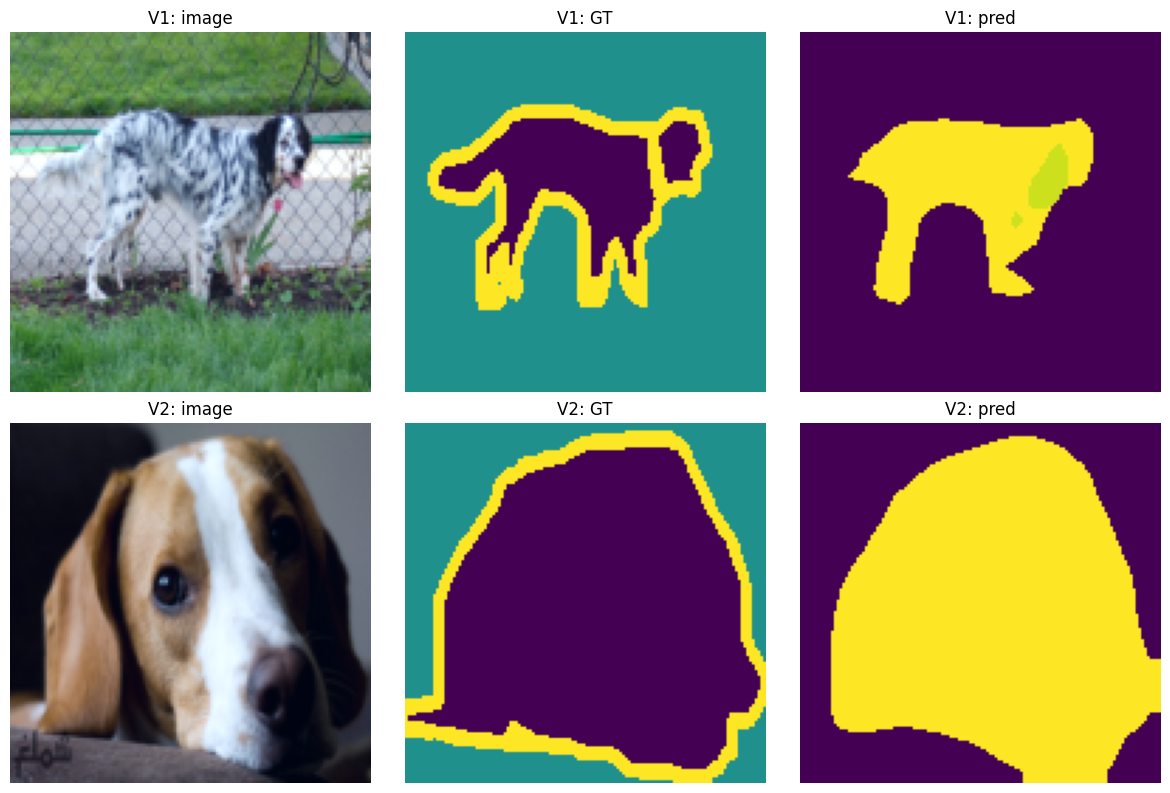

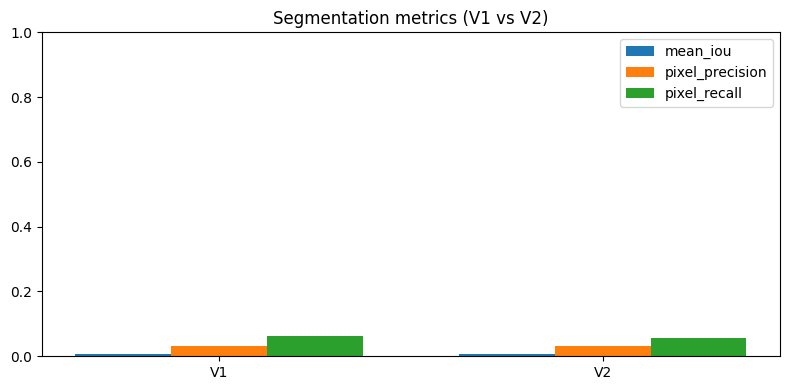

Сегментация завершена, артефакты сохранены.


In [ ]:
# Часть B: Segmentation (V1-V2)
import torchvision.models.segmentation as segmentation
from scipy.ndimage import binary_opening

model_seg = segmentation.deeplabv3_resnet50(
    weights=segmentation.DeepLabV3_ResNet50_Weights.DEFAULT
).to(device)
model_seg.eval()

# Явно задаем семантику маски OxfordIIITPet после target_transform: 0=foreground, 1=border, 2=background
PET_FOREGROUND_CLASS = 0
PET_BORDER_CLASS = 1
PET_BACKGROUND_CLASS = 2
POSTPROCESS_DESCRIPTIONS = {
    "V1": "Identity postprocess (raw argmax, без изменений маски)",
    "V2": "Morphological opening on foreground with reassignment removed pixels to background",
}
print(f"Foreground class index: {PET_FOREGROUND_CLASS}")
print(f"V1 postprocess: {POSTPROCESS_DESCRIPTIONS['V1']}")
print(f"V2 postprocess: {POSTPROCESS_DESCRIPTIONS['V2']}")

def compute_mean_iou(preds, targets, num_classes=3):
    ious = []
    for cls in range(num_classes):
        pred_mask = preds == cls
        target_mask = targets == cls
        intersection = (pred_mask & target_mask).sum().item()
        union = (pred_mask | target_mask).sum().item()
        if union > 0:
            ious.append(intersection / union)
    return float(np.mean(ious)) if ious else 0.0

def apply_v1_postprocess(preds):
    # V1: явное отсутствие постобработки (identity)
    return preds

def apply_v2_postprocess(preds):
    # V2: морфологическая очистка foreground-класса (0)
    out = preds.clone()
    for b in range(preds.shape[0]):
        fg = (preds[b].detach().cpu().numpy() == PET_FOREGROUND_CLASS)
        fg_clean = binary_opening(fg, structure=np.ones((3, 3), dtype=bool))
        fg_tensor = torch.from_numpy(fg_clean).to(preds.device)
        out[b][(preds[b] == PET_FOREGROUND_CLASS) & (~fg_tensor)] = PET_BACKGROUND_CLASS
    return out

def run_segmentation_eval(model, loader, mode="V1", max_batches=10):
    total_iou = 0.0
    total_batches = 0

    fg_tp = 0
    fg_fp = 0
    fg_fn = 0

    first_vis = None
    with torch.no_grad():
        for i, (images, masks) in enumerate(loader):
            if i >= max_batches:
                break
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            logits = model(images)["out"]
            preds = logits.argmax(1)
            if mode == "V1":
                preds = apply_v1_postprocess(preds)
            elif mode == "V2":
                preds = apply_v2_postprocess(preds)

            batch_iou = compute_mean_iou(preds, masks, num_classes=3)
            total_iou += batch_iou
            total_batches += 1

            pred_fg = preds == PET_FOREGROUND_CLASS
            true_fg = masks == PET_FOREGROUND_CLASS
            fg_tp += (pred_fg & true_fg).sum().item()
            fg_fp += (pred_fg & (~true_fg)).sum().item()
            fg_fn += ((~pred_fg) & true_fg).sum().item()

            if first_vis is None:
                first_vis = (images[0].detach().cpu(), masks[0].detach().cpu(), preds[0].detach().cpu())

    mean_iou = total_iou / max(total_batches, 1)
    pixel_precision = fg_tp / max(fg_tp + fg_fp, 1)
    pixel_recall = fg_tp / max(fg_tp + fg_fn, 1)

    return {
        "mean_iou": mean_iou,
        "pixel_precision": pixel_precision,
        "pixel_recall": pixel_recall,
        "first_vis": first_vis,
    }

metrics_v1 = run_segmentation_eval(model_seg, pet_loader, mode="V1", max_batches=10)
metrics_v2 = run_segmentation_eval(model_seg, pet_loader, mode="V2", max_batches=10)

# Визуализации: один файл с V1/V2
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for row, (name, m) in enumerate([("V1", metrics_v1), ("V2", metrics_v2)]):
    img, gt, pred = m["first_vis"]
    axes[row, 0].imshow((img.permute(1, 2, 0) * 0.229 + 0.485).clamp(0, 1))
    axes[row, 0].set_title(f"{name}: image")
    axes[row, 1].imshow(gt)
    axes[row, 1].set_title(f"{name}: GT")
    axes[row, 2].imshow(pred)
    axes[row, 2].set_title(f"{name}: pred")
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.savefig("artifacts/figures/segmentation_examples.png")
plt.show()

# Метрики сегментации
seg_metrics_df = pd.DataFrame([
    {"experiment_id": "V1", "mean_iou": metrics_v1["mean_iou"], "pixel_precision": metrics_v1["pixel_precision"], "pixel_recall": metrics_v1["pixel_recall"]},
    {"experiment_id": "V2", "mean_iou": metrics_v2["mean_iou"], "pixel_precision": metrics_v2["pixel_precision"], "pixel_recall": metrics_v2["pixel_recall"]},
])

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(2)
w = 0.25
ax.bar(x - w, seg_metrics_df["mean_iou"], width=w, label="mean_iou")
ax.bar(x, seg_metrics_df["pixel_precision"], width=w, label="pixel_precision")
ax.bar(x + w, seg_metrics_df["pixel_recall"], width=w, label="pixel_recall")
ax.set_xticks(x)
ax.set_xticklabels(seg_metrics_df["experiment_id"])
ax.set_ylim(0, 1)
ax.set_title("Segmentation metrics (V1 vs V2)")
ax.legend()
plt.tight_layout()
plt.savefig("artifacts/figures/segmentation_metrics.png")
plt.show()

segmentation_results = [
    {"experiment_id": "V1", "desc": "segmentation-base", "mean_iou": metrics_v1["mean_iou"], "precision": metrics_v1["pixel_precision"], "recall": metrics_v1["pixel_recall"]},
    {"experiment_id": "V2", "desc": "segmentation-postprocess", "mean_iou": metrics_v2["mean_iou"], "precision": metrics_v2["pixel_precision"], "recall": metrics_v2["pixel_recall"]},
]

pd.DataFrame(classification_results).to_csv("artifacts/runs_classification.csv", index=False)
pd.DataFrame(segmentation_results).to_csv("artifacts/runs_segmentation.csv", index=False)
print("Сегментация завершена, артефакты сохранены.")

Лучший конфиг классификации: C3 | val_acc=93.70%


C:\Users\Maxim\AppData\Local\Temp\ipykernel_51880\1477884414.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Test accuracy лучшей модели: 93.45%


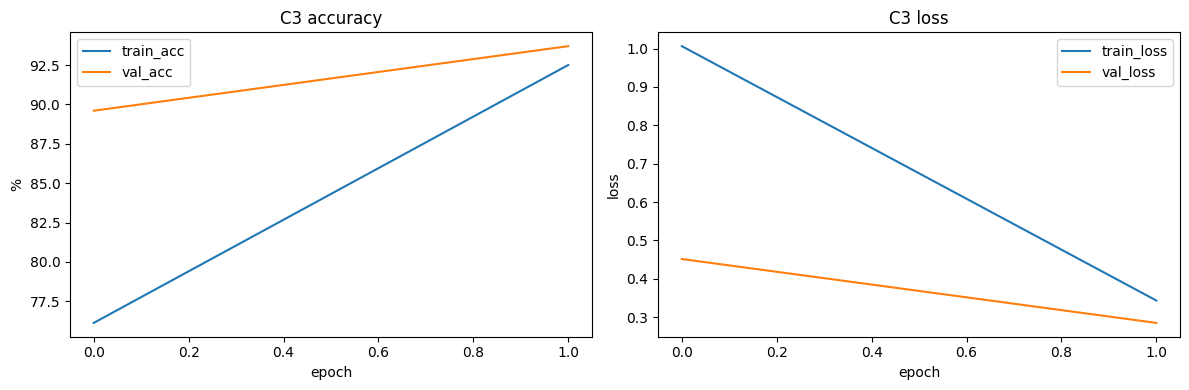

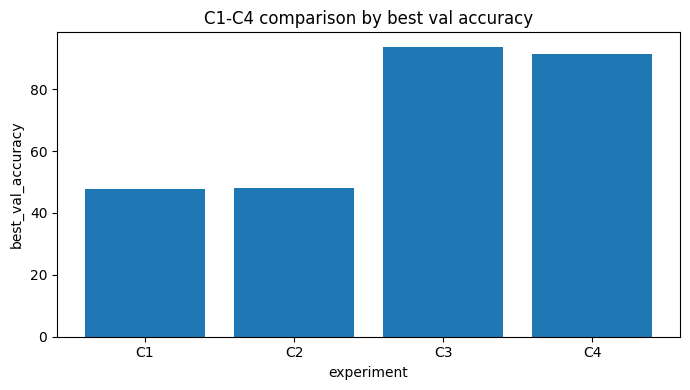

In [ ]:
# Финальный выбор лучшего классификатора и тестовая оценка
def build_model_for_config(config_id):
    if config_id in ("C1", "C2"):
        return SimpleCNN().to(device), test_loader_basic
    m = models.resnet18(weights=resnet18_weights)
    m.fc = nn.Linear(m.fc.in_features, 10)
    return m.to(device), test_loader_resnet

best_c = max(classification_results, key=lambda x: x["best_val_accuracy"])
best_config_id = best_c["experiment_id"]
print(f"Лучший конфиг классификации: {best_config_id} | val_acc={best_c['best_val_accuracy']:.2f}%")

best_model, best_test_loader = build_model_for_config(best_config_id)
best_model.load_state_dict(torch.load(f"artifacts/best_model_{best_config_id}.pth", map_location=device))

test_loss, test_acc = evaluate(best_model, best_test_loader, nn.CrossEntropyLoss(), device)
print(f"Test accuracy лучшей модели: {test_acc:.2f}%")

# Сохраняем итоговую лучшую модель в обязательный файл
torch.save(best_model.state_dict(), "artifacts/best_classifier.pt")

# Кривые лучшего прогона
best_history = history_by_config[best_config_id]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(best_history['train_acc'], label='train_acc')
axes[0].plot(best_history['val_acc'], label='val_acc')
axes[0].set_title(f"{best_config_id} accuracy")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("%")
axes[0].legend()
axes[1].plot(best_history['train_loss'], label='train_loss')
axes[1].plot(best_history['val_loss'], label='val_loss')
axes[1].set_title(f"{best_config_id} loss")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].legend()
plt.tight_layout()
plt.savefig("artifacts/figures/classification_curves_best.png")
plt.show()

# Сравнение C1-C4 по best val acc
compare_df = pd.DataFrame(classification_results).sort_values("experiment_id")
plt.figure(figsize=(7, 4))
plt.bar(compare_df["experiment_id"], compare_df["best_val_accuracy"])
plt.title("C1-C4 comparison by best val accuracy")
plt.xlabel("experiment")
plt.ylabel("best_val_accuracy")
plt.tight_layout()
plt.savefig("artifacts/figures/classification_compare.png")
plt.show()

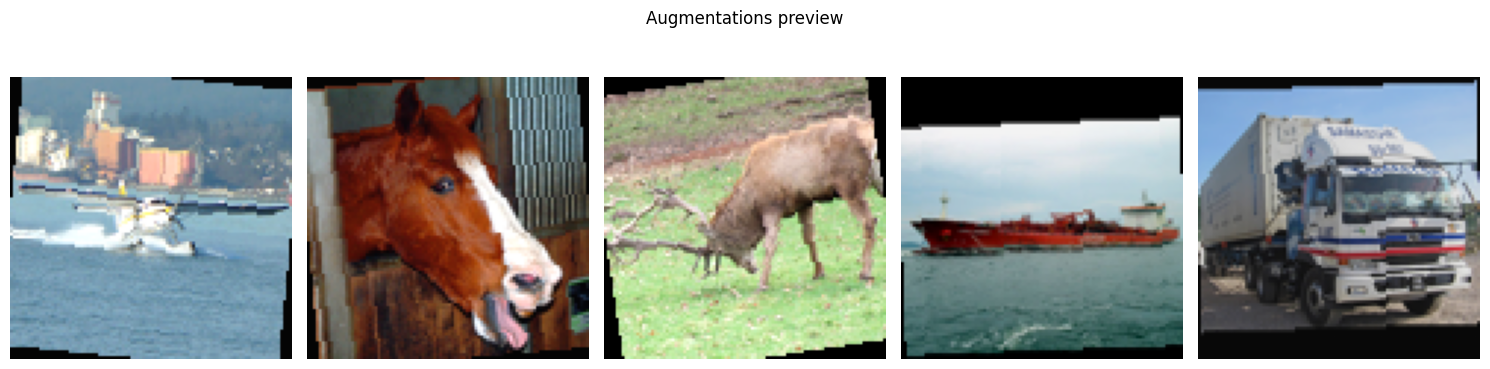

Финальные артефакты созданы:
- artifacts/runs.csv
- artifacts/best_classifier.pt
- artifacts/best_classifier_config.json
- artifacts/figures/classification_curves_best.png
- artifacts/figures/classification_compare.png
- artifacts/figures/augmentations_preview.png
- artifacts/figures/segmentation_examples.png
- artifacts/figures/segmentation_metrics.png


In [6]:
import json

# Превью аугментаций для отчета
preview_ds = STL10(root="data", split='train', download=False, transform=aug_transform)
preview_loader = DataLoader(preview_ds, batch_size=5, shuffle=True, num_workers=0)
imgs, _ = next(iter(preview_loader))

plt.figure(figsize=(15, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow((imgs[i].permute(1, 2, 0) * 0.5 + 0.5).clamp(0, 1))
    plt.axis("off")
plt.suptitle("Augmentations preview")
plt.tight_layout()
plt.savefig("artifacts/figures/augmentations_preview.png")
plt.show()

# Конфиг лучшей модели
best_desc_map = {x["experiment_id"]: x["desc"] for x in classification_results}
best_cfg = {
    "experiment_id": best_config_id,
    "dataset": "STL10",
    "architecture": "SimpleCNN" if best_config_id in ("C1", "C2") else "ResNet18",
    "mode": best_desc_map[best_config_id],
    "seed": 42,
    "optimizer": "Adam",
    "lr": 0.001,
    "epochs": 2,
    "best_val_accuracy": float(best_c["best_val_accuracy"]),
    "test_accuracy": float(test_acc),
    "transforms": {
        "basic": "Resize(96,96)+Normalize(0.5,0.5,0.5)",
        "aug": "Resize+Flip+Rotation+ColorJitter+Normalize",
        "resnet": "Resize(224,224)+ImageNetNormalize",
    },
}
with open("artifacts/best_classifier_config.json", "w", encoding="utf-8") as f:
    json.dump(best_cfg, f, indent=2, ensure_ascii=False)

# Итоговый runs.csv в формате задания
rows = []
for r in classification_results:
    rows.append({
        "experiment_id": r["experiment_id"],
        "task": "classification",
        "dataset": "STL10",
        "seed": 42,
        "model_summary": r["desc"],
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs_trained": 2,
        "best_val_accuracy": round(float(r["best_val_accuracy"]), 4),
        "test_accuracy": round(float(test_acc), 4) if r["experiment_id"] == best_config_id else None,
        "precision": None,
        "recall": None,
        "mean_iou": None,
        "notes": "best model" if r["experiment_id"] == best_config_id else "",
    })

for r in segmentation_results:
    rows.append({
        "experiment_id": r["experiment_id"],
        "task": "segmentation",
        "dataset": "OxfordIIITPet",
        "seed": 42,
        "model_summary": "DeepLabV3_ResNet50",
        "optimizer": None,
        "lr": None,
        "epochs_trained": None,
        "best_val_accuracy": None,
        "test_accuracy": None,
        "precision": round(float(r["precision"]), 4),
        "recall": round(float(r["recall"]), 4),
        "mean_iou": round(float(r["mean_iou"]), 4),
        "notes": r["desc"],
    })

runs_df = pd.DataFrame(rows)
runs_df.to_csv("artifacts/runs.csv", index=False)
print("Финальные артефакты созданы:")
print("- artifacts/runs.csv")
print("- artifacts/best_classifier.pt")
print("- artifacts/best_classifier_config.json")
print("- artifacts/figures/classification_curves_best.png")
print("- artifacts/figures/classification_compare.png")
print("- artifacts/figures/augmentations_preview.png")
print("- artifacts/figures/segmentation_examples.png")
print("- artifacts/figures/segmentation_metrics.png")